В цьому домашньому завданні ми знову працюємо з даними з нашого змагання ["Bank Customer Churn Prediction (DLU Course)"](https://www.kaggle.com/t/7c080c5d8ec64364a93cf4e8f880b6a0).

Тут ми побудуємо рішення задачі класифікації з використанням алгоритмів бустингу: XGBoost та LightGBM, а також використаємо бібліотеку HyperOpt для оптимізації гіперпараметрів.

0. Зчитайте дані `train.csv` в змінну `raw_df` та скористайтесь наведеним кодом нижче аби розділити дані на трнувальні та валідаційні і розділити дані на ознаки з матириці Х та цільову змінну. Назви змінних `train_inputs, train_targets, train_inputs, train_targets` можна змінити на ті, які Вам зручно.

  Наведений скрипт - частина отриманого мною скрипта для обробки даних. Ми тут не викнуємо масштабування та обробку категоріальних змінних, бо хочемо це делегувати алгоритмам, які будемо використовувати. Якщо щось не розумієте в наведених скриптах, рекомендую розібратись: навичка читати код - важлива складова роботи в машинному навчанні.

In [84]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from typing import Tuple, Dict, Any


def split_train_val(df: pd.DataFrame, target_col: str, test_size: float = 0.2, random_state: int = 42) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Split the dataframe into training and validation sets.

    Args:
        df (pd.DataFrame): The raw dataframe.
        target_col (str): The target column for stratification.
        test_size (float): The proportion of the dataset to include in the validation split.
        random_state (int): Random state for reproducibility.

    Returns:
        Tuple[pd.DataFrame, pd.DataFrame]: Training and validation dataframes.
    """
    train_df, val_df = train_test_split(df, test_size=test_size, random_state=random_state, stratify=df[target_col])
    return train_df, val_df


def separate_inputs_targets(df: pd.DataFrame, input_cols: list, target_col: str) -> Tuple[pd.DataFrame, pd.Series]:
    """
    Separate inputs and targets from the dataframe.

    Args:
        df (pd.DataFrame): The dataframe.
        input_cols (list): List of input columns.
        target_col (str): Target column.

    Returns:
        Tuple[pd.DataFrame, pd.Series]: DataFrame of inputs and Series of targets.
    """
    inputs = df[input_cols].copy()
    targets = df[target_col].copy()
    return inputs, targets

In [85]:
# read data from csv
raw_df = pd.read_csv('train.csv')

In [86]:
raw_df.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15779985.0,Nwankwo,678.0,France,Male,29.0,4.0,0.00,3.0,1.0,0.0,180626.36,0.0
1,1,15650086.0,Ch'in,687.0,France,Female,34.0,1.0,0.00,2.0,0.0,1.0,63736.17,0.0
2,2,15733602.0,Thompson,682.0,France,Female,52.0,6.0,0.00,3.0,0.0,0.0,179655.87,1.0
3,3,15645794.0,Macleod,753.0,Germany,Male,44.0,6.0,83347.25,2.0,1.0,0.0,161407.48,0.0
4,4,15633840.0,Hsia,544.0,Germany,Female,55.0,0.0,107747.57,1.0,1.0,0.0,176580.86,1.0


In [87]:
# selection of columns
input_cols = list(raw_df.columns[3:-1])
target_col = 'Exited'

print(input_cols)
print(target_col)

['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']
Exited


In [88]:
train_df, val_df = split_train_val(raw_df, target_col=target_col)

In [89]:
train_df.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
7180,7180,15652218.0,Mays,682.0,France,Male,30.0,1.0,131394.56,1.0,1.0,1.0,143952.24,0.0
10393,10393,15592937.0,Ch'eng,684.0,France,Female,39.0,2.0,178058.06,1.0,1.0,0.0,145518.31,0.0
80,80,15774586.0,Ch'in,705.0,Germany,Male,35.0,6.0,116320.68,2.0,1.0,0.0,174431.01,0.0
3365,3365,15780572.0,K?,669.0,Spain,Male,58.0,0.0,0.00,2.0,0.0,1.0,51565.98,0.0
12236,12236,15642099.0,Trevisani,707.0,France,Male,21.0,3.0,0.00,2.0,1.0,1.0,148564.76,0.0


In [137]:
# separate inputs and targets
train_inputs, train_targets = separate_inputs_targets(train_df, input_cols=input_cols, target_col=target_col)
val_inputs, val_targets = separate_inputs_targets(val_df, input_cols=input_cols, target_col=target_col)

In [91]:
train_inputs.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
7180,682.0,France,Male,30.0,1.0,131394.56,1.0,1.0,1.0,143952.24
10393,684.0,France,Female,39.0,2.0,178058.06,1.0,1.0,0.0,145518.31
80,705.0,Germany,Male,35.0,6.0,116320.68,2.0,1.0,0.0,174431.01
3365,669.0,Spain,Male,58.0,0.0,0.00,2.0,0.0,1.0,51565.98
12236,707.0,France,Male,21.0,3.0,0.00,2.0,1.0,1.0,148564.76


In [92]:
train_inputs.shape, val_inputs.shape

((12000, 10), (3000, 10))

1. В тренувальному та валідаційному наборі перетворіть категоріальні ознаки на тип `category`. Можна це зробити двома способами:
 1. `df[col_name].astype('category')`, як було продемонстровано в лекції
 2. використовуючи метод `pd.Categorical(df[col_name])`

In [93]:
# select categorical features
cat_cols = train_inputs.select_dtypes(include='object').columns
cat_cols

Index(['Geography', 'Gender'], dtype='object')

In [94]:
# transfrom categorical features into 'category' data type
train_inputs[cat_cols] = train_inputs[cat_cols].astype('category')
val_inputs[cat_cols] = val_inputs[cat_cols].astype('category')

In [95]:
train_inputs.dtypes

,0
CreditScore,float64
Geography,category
Gender,category
Age,float64
Tenure,float64
Balance,float64
NumOfProducts,float64
HasCrCard,float64
IsActiveMember,float64
EstimatedSalary,float64


In [96]:
val_inputs.dtypes

,0
CreditScore,float64
Geography,category
Gender,category
Age,float64
Tenure,float64
Balance,float64
NumOfProducts,float64
HasCrCard,float64
IsActiveMember,float64
EstimatedSalary,float64


2. Навчіть на отриманих даних модель `XGBoostClassifier`. Параметри алгоритму встановіть на свій розсуд, ми далі будемо їх тюнити. Рекомендую тренувати не дуже складну модель.

  Опис всіх конфігураційних параметрів XGBoostClassifier - тут https://xgboost.readthedocs.io/en/stable/parameter.html#global-config

  **Важливо:** зробіть такі налаштування `XGBoostClassifier` аби він самостійно обробляв незаповнені значення в даних і обробляв категоріальні колонки.

  Можна також, якщо працюєте в Google Colab, увімкнути можливість використання GPU (`Runtime -> Change runtime type -> T4 GPU`) і встановити параметр `device='cuda'` в `XGBoostClassifier` для пришвидшення тренування бустинг моделі.
  
  Після тренування моделі
  1. Виміряйте точність з допомогою AUROC на тренувальному та валідаційному наборах.
  2. Зробіть висновок про отриману модель: вона хороша/погана, чи є high bias/high variance?
  3. Порівняйте якість цієї моделі з тою, що ви отрмали з використанням DecisionTrees раніше. Чи вийшло покращити якість?

In [97]:
import xgboost as xgb

In [98]:
RANDOM_STATE = 42

In [99]:
# setup XGBoostClassifier model
xgboost_clf = xgb.XGBClassifier(
    random_state=RANDOM_STATE,
    max_depth = 4,
    n_estimators = 8,
    enable_categorical = True,
    missing=np.nan, # there are no missing values in out data
    device = 'cuda'
)

In [100]:
# train the model
xgboost_clf.fit(train_inputs, train_targets)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [22:13:55] WARNING: /__w/xgboost/xgboost/src/context.cc:53: No visible GPU is found, setting device to CPU.
  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [22:13:55] WARNING: /__w/xgboost/xgboost/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device='cuda', early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=8,
              n_jobs=None, num_parallel_tree=None, ...)

In [101]:
# predict usinf the model
train_pred_proba_xgb = xgboost_clf.predict_proba(train_inputs)
val_pred_proba_xgb = xgboost_clf.predict_proba(val_inputs);

In [102]:
from sklearn.metrics import roc_curve, auc

def compute_auroc(targets, probabilities):
  # Compute ROC curve (Receiver Operating Characteristic curve)
  fpr, tpr, thresholds = roc_curve(targets, probabilities)
  # Compute AUROC (ara under the ROC curve)
  roc_auc = auc(fpr, tpr)

  return roc_auc

In [103]:
# calculate metric value
print(f'AUROC for Training data: {compute_auroc(train_targets, train_pred_proba_xgb[:,1]):.5f}')
print(f'AUROC for Validation data: {compute_auroc(val_targets, val_pred_proba_xgb[:,1]):.5f}')

AUROC for Training data: 0.93536
AUROC for Validation data: 0.93338


**Висновок**

Модель вийшла достатньо добра: значення метрики високе і майже однакове як на тренувальних, так і на валідаційних даних, тобто, модель не пернавчена і не недонавчена.

У попередньому домашньому завданні з використаннями тюнінгованого дерева вдалось досягти наступних значень метрики: 0.91693 (тренувальні), 0.91662 (валідаційні). Таким чином, поточна модель XGBoost показала кращий рещультат.

3. Використовуючи бібліотеку `Hyperopt` і приклад пошуку гіперпараметрів для `XGBoostClassifier` з лекції знайдіть оптимальні значення гіперпараметрів `XGBoostClassifier` для нашої задачі. Задайте свою сітку гіперпараметрів виходячи з тих параметрів, які ви б хотіли перебрати. Поставте кількість раундів в підборі гіперпараметрів рівну **20**.

  **Увага!** Для того, аби скористатись hyperopt, нам треба задати функцію `objective`. В ній ми маємо задати loss - це може будь-яка метрика, але бажано використовувтаи ту, яка цільова в вашій задачі. Чим менший лосс - тим ліпша модель на думку hyperopt. Тож, тут нам треба задати loss - негативне значення AUROC. В лекції ми натомість використовували Accuracy.

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення гіперпараметрів
    - створіть в окремій зміній `final_clf` модель `XGBoostClassifier` з найкращими гіперпараметрами
    - навчіть модель `final_clf`
    - оцініть якість моделі `final_clf` на тренувальній і валідаційній вибірках з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи стала вона краще порівняно з попереднім пунктом (2) цього завдання?

In [104]:
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials, rand

In [105]:
# define objective function
def objective(params):
    clf = xgb.XGBClassifier(
        n_estimators=int(params['n_estimators']),
        random_state=RANDOM_STATE,
        learning_rate=params['learning_rate'],
        max_depth=int(params['max_depth']),
        min_child_weight=params['min_child_weight'],  # Мінімальна сума ваг всіх вибірок, необхідна в кінцевому вузлі
        subsample=params['subsample'],  # Частка вибірок, що використовуються для побудови кожного дерева
        colsample_bytree=params['colsample_bytree'],  # Частка ознак, що використовуються при побудові кожного дерева
        gamma=params['gamma'],  # Мінімальне зменшення втрат, необхідне для виконання поділу
        reg_alpha=params['reg_alpha'],  # Параметр регуляризації L1 (Lasso)
        reg_lambda=params['reg_lambda'],  # Параметр регуляризації L2 (Ridge)
        enable_categorical=True,
        use_label_encoder=False,
        missing=np.nan,
        device='cuda',
        early_stopping_rounds=20
    )
    # fit classification model
    clf.fit(
            train_inputs,
            train_targets,
            eval_set=[(val_inputs, val_targets)],
            verbose=False)
    # predict probabilities
    pred_proba = clf.predict_proba(val_inputs)
    # calculate AUROC
    auroc = compute_auroc(val_targets, pred_proba[:,1])

    return {'loss': -auroc, 'status': STATUS_OK}

In [106]:
# define parameter search space
params_space = {
    'n_estimators': hp.quniform('n_estimators', 30, 500, 20),
    'learning_rate': hp.uniform('learning_rate', 0.01, 0.1),
    'max_depth': hp.quniform('max_depth', 3, 20, 1),
    'min_child_weight': hp.quniform('min_child_weight', 1, 20, 1),
    'subsample': hp.uniform('subsample', 0.5, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 1.0),
    'gamma': hp.uniform('gamma', 0, 0.1),
    'reg_alpha': hp.uniform('reg_alpha', 0, 1),
    'reg_lambda': hp.uniform('reg_lambda', 0, 1)
}


In [107]:
# optimization
trials = Trials()
best_config = fmin(fn=objective, space=params_space, algo=tpe.suggest, max_evals=20, trials=trials) # rstate=np.random.default_rng(RANDOM_STATE)

  0%|          | 0/20 [00:00<?, ?trial/s, best loss=?]

/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [22:13:56] WARNING: /__w/xgboost/xgboost/src/context.cc:53: No visible GPU is found, setting device to CPU.
  self.starting_round = model.num_boosted_rounds()

/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [22:13:56] WARNING: /__w/xgboost/xgboost/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  self.starting_round = model.num_boosted_rounds()

/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [22:13:56] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()



  5%|▌         | 1/20 [00:00<00:06,  2.90trial/s, best loss: -0.9365004458467658]

/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [22:13:56] WARNING: /__w/xgboost/xgboost/src/context.cc:53: No visible GPU is found, setting device to CPU.
  self.starting_round = model.num_boosted_rounds()

/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [22:13:56] WARNING: /__w/xgboost/xgboost/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  self.starting_round = model.num_boosted_rounds()

/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [22:13:56] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()



 10%|█         | 2/20 [00:00<00:08,  2.20trial/s, best loss: -0.9365004458467658]

...

 90%|█████████ | 18/20 [00:09<00:01,  1.15trial/s, best loss: -0.9365004458467658]

/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [22:14:06] WARNING: /__w/xgboost/xgboost/src/context.cc:53: No visible GPU is found, setting device to CPU.
  self.starting_round = model.num_boosted_rounds()

/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [22:14:06] WARNING: /__w/xgboost/xgboost/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  self.starting_round = model.num_boosted_rounds()

/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [22:14:06] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()



 95%|█████████▌| 19/20 [00:11<00:00,  1.01trial/s, best loss: -0.9365004458467658]

/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [22:14:07] WARNING: /__w/xgboost/xgboost/src/context.cc:53: No visible GPU is found, setting device to CPU.
  self.starting_round = model.num_boosted_rounds()

/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [22:14:07] WARNING: /__w/xgboost/xgboost/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  self.starting_round = model.num_boosted_rounds()

/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [22:14:07] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()



100%|██████████| 20/20 [00:11<00:00,  1.71trial/s, best loss: -0.9365004458467658]


In [108]:
# parameter conversion (for integers)
best_config['n_estimators'] = int(best_config['n_estimators'])
best_config['max_depth'] = int(best_config['max_depth'])
best_config['min_child_weight'] = int(best_config['min_child_weight'])

print("Best hyperparameter configuration: ", best_config)


Best hyperparameter configuration:  {'colsample_bytree': np.float64(0.5984891769675724), 'gamma': np.float64(0.05135406999507639), 'learning_rate': np.float64(0.056997057521398296), 'max_depth': 16, 'min_child_weight': 15, 'n_estimators': 80, 'reg_alpha': np.float64(0.6865523611954993), 'reg_lambda': np.float64(0.8897797184494733), 'subsample': np.float64(0.9805201817054097)}


In [109]:
# setup model with best hyperparameters configuration
final_clf = xgb.XGBClassifier(
    random_state=RANDOM_STATE,
    n_estimators=best_config['n_estimators'],
    learning_rate=best_config['learning_rate'],
    max_depth=best_config['max_depth'],
    min_child_weight=best_config['min_child_weight'],
    subsample=best_config['subsample'],
    colsample_bytree=best_config['colsample_bytree'],
    gamma=best_config['gamma'],
    reg_alpha=best_config['reg_alpha'],
    reg_lambda=best_config['reg_lambda'],
    enable_categorical=True,
    #use_label_encoder=False,
    missing=np.nan,
    device='cuda',
)

In [110]:
# train best model, make prediction and evaluate
final_clf.fit(train_inputs, train_targets)

train_final_pred_proba_xgb = final_clf.predict_proba(train_inputs)
val_final_pred_proba_xgb = final_clf.predict_proba(val_inputs)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [22:14:07] WARNING: /__w/xgboost/xgboost/src/context.cc:53: No visible GPU is found, setting device to CPU.
  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [22:14:07] WARNING: /__w/xgboost/xgboost/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)


In [111]:
# evaluate best model on train and validation data
print(f'AUROC for Training data: {compute_auroc(train_targets, train_final_pred_proba_xgb[:,1]):.5f}')
print(f'AUROC for Validation data: {compute_auroc(val_targets, val_final_pred_proba_xgb[:,1]):.5f}')

AUROC for Training data: 0.95343
AUROC for Validation data: 0.93650


**Висновок:**

Модель стала дещо кращою порівняно з попередньою моделлю без тюнінгу гіперпараметрів:
- без тюнінгу (попередня):
  - AUROC for Training data: 0.93536
  - AUROC for Validation data: 0.93338
- з тюнінгом (поточна, без фіксації random state в fmin) - результати наступного порядку (змінюються після перезапуску коду):
  - AUROC for Training data: 0.95343
  - AUROC for Validation data: 0.93650

Поточна модель демонструє помірні ознаки перенавчання, проте є достатньо гарною моделлю здатною узагальнювати дані.

АЛЕ! Якщо фіксувати random state у ф-ції `fmin` (`rstate=np.random.default_rng(RANDOM_STATE)`), то результуючі метрики у поточної моделі будуть теж фіксованими і незмінними після перезапуску коду:
  - AUROC for Training data: 0.97229
  - AUROC for Validation data: 0.93313

Така модель має ознаки перенавчання, хоча і демонструє все ще непогану роботу на валідаційних даних.




4. Навчіть на наших даних модель LightGBM. Параметри алгоритму встановіть на свій розсуд, ми далі будемо їх тюнити. Рекомендую тренувати не дуже складну модель.

  Опис всіх конфігураційних параметрів LightGBM - тут https://lightgbm.readthedocs.io/en/latest/Parameters.html

  **Важливо:** зробіть такі налаштування LightGBM аби він самостійно обробляв незаповнені значення в даних і обробляв категоріальні колонки.

  Аби передати категоріальні колонки в LightGBM - необхідно виявити їх індекси і передати в параметрі `cat_feature=cat_feature_indexes`

  Після тренування моделі
  1. Виміряйте точність з допомогою AUROC на тренувальному та валідаційному наборах.
  2. Зробіть висновок про отриману модель: вона хороша/погана, чи є high bias/high variance?
  3. Порівняйте якість цієї моделі з тою, що ви отрмали з використанням XGBoostClassifier раніше. Чи вийшло покращити якість?

In [112]:
import lightgbm as lgb

In [113]:
# categorical columns indices
cat_feature_indexes = [train_inputs.columns.get_loc(col) for col in cat_cols]
cat_feature_indexes

[1, 2]

In [114]:
# setup LightLGBMClassifier
lgb_clf = lgb.LGBMClassifier(
    max_depth=4,
    n_estimators=8,
    learning_rate=0.1,
    cat_feature=cat_feature_indexes,
    random_state=RANDOM_STATE
    #missing=np.nan#,
    # device='cuda'
)

In [115]:
# train model
lgb_clf.fit(train_inputs, train_targets, eval_set=[(val_inputs, val_targets)])

[LightGBM] [Warning] categorical_feature is set with categorical_column=1,2, will be overridden by cat_feature=1,2. Current value: categorical_feature=1,2
[LightGBM] [Info] Number of positive: 2442, number of negative: 9558
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001443 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 843
[LightGBM] [Info] Number of data points in the train set: 12000, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.203500 -> initscore=-1.364561
[LightGBM] [Info] Start training from score -1.364561
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

LGBMClassifier(cat_feature=[1, 2], max_depth=4, n_estimators=8, random_state=42)

In [116]:
# make probability prediction for train and validation data
train_pred_proba_lgbm = lgb_clf.predict_proba(train_inputs)
val_pred_proba_lgbm = lgb_clf.predict_proba(val_inputs)

In [117]:
# evaluate current model on train and validation data
print(f'AUROC for Training data: {compute_auroc(train_targets, train_pred_proba_lgbm[:,1]):.5f}')
print(f'AUROC for Validation data: {compute_auroc(val_targets, val_pred_proba_lgbm[:,1]):.5f}')

AUROC for Training data: 0.92616
AUROC for Validation data: 0.92455


**Висновок:**

Модель робить достатньо гарні передбачення, не демонструє ознак перенавчання чи недонавчання, має гарну здатність узагальнбвати дані.
Порівняємо значення метрики для моделей:
- XGBoost (без тюнінгу):
  - AUROC for Training data: 0.93536
  - AUROC for Validation data: 0.93338
- XGBoost (з тюнінгом, без фіксації random state, змінюються після перезапуску):
  - AUROC for Training data: 0.95343
  - AUROC for Validation data: 0.93650
- XGBoost (з тюнінгом, з фіксацією random state в ф-ції fmin):
  - AUROC for Training data: 0.97229
  - AUROC for Validation data: 0.93313
- LightGBM (без тюнінгу, параметри як у XGBoost без тюнінгу):
  - AUROC for Training data: 0.92616
  - AUROC for Validation data: 0.92455

Модель LightGBM без тюнінгу вийшла трох гіршою, ніж XGBoost без тюнінгу, навіть з аналогічними параметрами. XGBoost з тюнінгом працює трохи краще з трьох моделей.

5. Використовуючи бібліотеку `Hyperopt` і приклад пошуку гіперпараметрів для `LightGBM` з лекції знайдіть оптимальні значення гіперпараметрів `LightGBM` для нашої задачі. Задайте свою сітку гіперпараметрів виходячи з тих параметрів, які ви б хотіли перебрати. Поставте кількість раундів в підборі гіперпараметрів рівну **10**.

  **Увага!** Для того, аби скористатись hyperopt, нам треба задати функцію `objective`. І тут ми також ставимо loss - негативне значення AUROC, як і при пошуці гіперпараметрів для XGBoost. До речі, можна спробувати написати код так, аби в objective передавати лише модель і не писати схожий код двічі :)

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення гіперпараметрів
    - створіть в окремій зміній `final_lgb_clf` модель `LightGBM` з найкращими гіперпараметрами
    - навчіть модель `final_lgb_clf`
    - оцініть якість моделі `final_lgb_clf` на тренувальній і валідаційній вибірках з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи стала вона краще порівняно з попереднім пунктом (4) цього завдання?

In [119]:
# define function to calculate objective
def objective_lgbm(params):
    clf = lgb.LGBMClassifier(
        random_state=RANDOM_STATE,
        n_estimators=int(params['n_estimators']),  # Кількість дерев у ансамблі (кількість ітерацій бустингу)
        learning_rate=params['learning_rate'],  # Коефіцієнт, на який зменшується внесок кожного доданого дерева
        max_depth=int(params['max_depth']),  # Максимальна глибина кожного дерева
        num_leaves=int(params['num_leaves']),  # Максимальна кількість листків, що дозволяємо кожному дереву мати.
        min_child_weight=params['min_child_weight'],  # Мінімальна сума ваг всіх вибірок, необхідна в кінцевому вузлі
        subsample=params['subsample'],  # Частка вибірок, що використовуються для побудови кожного дерева
        colsample_bytree=params['colsample_bytree'],  # Частка ознак, що використовуються при побудові кожного дерева
        reg_alpha=params['reg_alpha'],  # Параметр регуляризації L1 (Lasso)
        reg_lambda=params['reg_lambda'],  # Параметр регуляризації L2 (Ridge)
        min_split_gain=params['min_split_gain'],  # Мінімальне зменшення втрат, необхідне для виконання поділу
        cat_feature=cat_feature_indexes  # Індекси категорійних ознак
    )
    # train classification model
    clf.fit(train_inputs,
            train_targets,
            eval_set=[(val_inputs, val_targets)])
    # predict probabilities for validation set
    pred_proba = clf.predict_proba(val_inputs)
    # calculate AUROC metric
    auroc = compute_auroc(val_targets, pred_proba[:,1])

    return {'loss': -auroc, 'status': STATUS_OK}

In [120]:
# define hyperparameter search space for LightGBM
space_lgbm = {
    'n_estimators': hp.quniform('n_estimators', 50, 500, 25),
    'learning_rate': hp.uniform('learning_rate', 0.01, 0.3),
    'max_depth': hp.quniform('max_depth', 3, 15, 1),
    'num_leaves': hp.quniform('num_leaves', 20, 150, 1),
    'min_child_weight': hp.quniform('min_child_weight', 1, 10, 1),
    'subsample': hp.uniform('subsample', 0.5, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 1.0),
    'reg_alpha': hp.uniform('reg_alpha', 0, 1),
    'reg_lambda': hp.uniform('reg_lambda', 0, 1),
    'min_split_gain': hp.uniform('min_split_gain', 0, 0.1)
}

In [121]:
# optimize hyperparameter configuration
trials_lgbm = Trials()
best_config_lgbm = fmin(fn=objective_lgbm, space=space_lgbm, algo=tpe.suggest, max_evals=10, trials=trials_lgbm) # rstate=np.random.default_rng(RANDOM_STATE)

[LightGBM] [Warning] categorical_feature is set with categorical_column=1,2, will be overridden by cat_feature=1,2. Current value: categorical_feature=1,2
[LightGBM] [Info] Number of positive: 2442, number of negative: 9558
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001603 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 843
[LightGBM] [Info] Number of data points in the train set: 12000, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.203500 -> initscore=-1.364561
[LightGBM] [Info] Start training from score -1.364561
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

In [122]:
# loss funtion value in all evaluations
trials_lgbm.results

[{'loss': -0.9220097400370397, 'status': 'ok'},
 {'loss': -0.9240215378283834, 'status': 'ok'},
 {'loss': -0.9310000685918101, 'status': 'ok'},
 {'loss': -0.9317456615680088, 'status': 'ok'},
 {'loss': -0.9191913025584745, 'status': 'ok'},
 {'loss': -0.9240064476301528, 'status': 'ok'},
 {'loss': -0.9251046025104603, 'status': 'ok'},
 {'loss': -0.9276260374511284, 'status': 'ok'},
 {'loss': -0.9358790040469167, 'status': 'ok'},
 {'loss': -0.9210624871390355, 'status': 'ok'}]

In [123]:
# parameter conversion (for integers)
best_config_lgbm['n_estimators'] = int(best_config_lgbm['n_estimators'])
best_config_lgbm['max_depth'] = int(best_config_lgbm['max_depth'])
best_config_lgbm['num_leaves'] = int(best_config_lgbm['num_leaves'])
best_config_lgbm['min_child_weight'] = int(best_config_lgbm['min_child_weight'])

print("Best hyperparameter configuration: ", best_config_lgbm)

Best hyperparameter configuration:  {'colsample_bytree': np.float64(0.7699126746813036), 'learning_rate': np.float64(0.01692713271551037), 'max_depth': 5, 'min_child_weight': 3, 'min_split_gain': np.float64(0.003228362690557285), 'n_estimators': 150, 'num_leaves': 126, 'reg_alpha': np.float64(0.30790216734425624), 'reg_lambda': np.float64(0.44623276545119617), 'subsample': np.float64(0.5436804971293139)}


In [125]:
# setup model with best hyperparameters configuration
final_lgb_clf = lgb.LGBMClassifier(
    n_estimators=best_config_lgbm['n_estimators'],
    learning_rate=best_config_lgbm['learning_rate'],
    max_depth=best_config_lgbm['max_depth'],
    num_leaves=best_config_lgbm['num_leaves'],
    min_child_weight=best_config_lgbm['min_child_weight'],
    subsample=best_config_lgbm['subsample'],
    colsample_bytree=best_config_lgbm['colsample_bytree'],
    reg_alpha=best_config_lgbm['reg_alpha'],
    reg_lambda=best_config_lgbm['reg_lambda'],
    min_split_gain=best_config_lgbm['min_split_gain'],
    cat_feature=cat_feature_indexes,
    #missing=np.nan
)

In [126]:
# train best model, make prediction and evaluate
final_lgb_clf.fit(train_inputs, train_targets, eval_set=[(val_inputs, val_targets)])

[LightGBM] [Warning] categorical_feature is set with cat_feature=1,2, categorical_column=1,2 will be ignored. Current value: categorical_feature=1,2
[LightGBM] [Info] Number of positive: 2442, number of negative: 9558
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002481 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 843
[LightGBM] [Info] Number of data points in the train set: 12000, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.203500 -> initscore=-1.364561
[LightGBM] [Info] Start training from score -1.364561
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

LGBMClassifier(cat_feature=[1, 2],
               colsample_bytree=np.float64(0.7699126746813036),
               learning_rate=np.float64(0.01692713271551037), max_depth=5,
               min_child_weight=3,
               min_split_gain=np.float64(0.003228362690557285),
               n_estimators=150, num_leaves=126,
               reg_alpha=np.float64(0.30790216734425624),
               reg_lambda=np.float64(0.44623276545119617),
               subsample=np.float64(0.5436804971293139))

In [127]:
# make probability prediction for train and validation data
train_final_pred_proba_lgbm = final_lgb_clf.predict_proba(train_inputs)
val_final_pred_proba_lgbm = final_lgb_clf.predict_proba(val_inputs)

In [128]:
# evaluate best model on train and validation data
print(f'AUROC for Training data: {compute_auroc(train_targets, train_final_pred_proba_lgbm[:,1]):.5f}')
print(f'AUROC for Validation data: {compute_auroc(val_targets, val_final_pred_proba_lgbm[:,1]):.5f}')

AUROC for Training data: 0.94316
AUROC for Validation data: 0.93550


**Висновок:**

Порівняємо значення метрики для моделей:
- XGBoost (без тюнінгу):
  - AUROC for Training data: 0.93536
  - AUROC for Validation data: 0.93338
- XGBoost (з тюнінгом, без фіксації random state, змінюються після перезапуску):
  - AUROC for Training data: 0.95343
  - AUROC for Validation data: 0.93650
- XGBoost (з тюнінгом, з фіксацією random state в ф-ції fmin):
  - AUROC for Training data: 0.97229
  - AUROC for Validation data: 0.93313
- LightGBM (без тюнінгу, параметри як у XGBoost без тюнінгу):
  - AUROC for Training data: 0.92616
  - AUROC for Validation data: 0.92455
- LightGBM (з тюнінгом, без фіксації random state, змінюються після перезапуску):
  - AUROC for Training data: 0.94316
  - AUROC for Validation data: 0.93550
  
Оцінюючи метрику якості на валідаційних даних, модель LightGBM з тюнінгом стала помітно кращою за попередню модель без тюнінгу гіперпараметрів. Якщо порівнбвати здатність узагальнювати дані, то модель без тюнінгу справляється з цим трохи краще, але модель з тюнінгом робить узагальнення також достатньо гарно (судячи по величинах метрики отриманих у цій сесії/запуску).

6. Оберіть модель з експериментів в цьому ДЗ і зробіть новий `submission` на Kaggle та додайте код для цього і скріншот скора на публічному лідерборді.
  
  **Напишіть коментар, чому ви обрали саме цю модель?**

  І я вас вітаю - це останнє завдання з цим набором даних 💪 На цьому етапі корисно проаналізувати, які моделі показали себе найкраще і подумати, чому.

In [129]:
# load test data
test_raw_df = pd.read_csv('test.csv')
test_raw_df.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,15000,15594796.0,Chu,584.0,Germany,Male,30.0,2.0,146053.66,1.0,1.0,1.0,157891.86
1,15001,15642821.0,Mazzi,551.0,France,Male,39.0,5.0,0.00,2.0,1.0,1.0,67431.28
2,15002,15716284.0,Onyekachi,706.0,France,Male,43.0,8.0,0.00,2.0,1.0,0.0,156768.45
3,15003,15785078.0,Martin,717.0,Spain,Male,45.0,3.0,0.00,1.0,1.0,1.0,166909.87
4,15004,15662955.0,Kenechukwu,592.0,Spain,Male,43.0,8.0,0.00,2.0,1.0,1.0,143681.97


In [141]:
# preprocess test data
test_inputs = test_raw_df[input_cols].copy()
test_inputs.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,584.0,Germany,Male,30.0,2.0,146053.66,1.0,1.0,1.0,157891.86
1,551.0,France,Male,39.0,5.0,0.00,2.0,1.0,1.0,67431.28
2,706.0,France,Male,43.0,8.0,0.00,2.0,1.0,0.0,156768.45
3,717.0,Spain,Male,45.0,3.0,0.00,1.0,1.0,1.0,166909.87
4,592.0,Spain,Male,43.0,8.0,0.00,2.0,1.0,1.0,143681.97


In [143]:
train_inputs.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
7180,682.0,France,Male,30.0,1.0,131394.56,1.0,1.0,1.0,143952.24
10393,684.0,France,Female,39.0,2.0,178058.06,1.0,1.0,0.0,145518.31
80,705.0,Germany,Male,35.0,6.0,116320.68,2.0,1.0,0.0,174431.01
3365,669.0,Spain,Male,58.0,0.0,0.00,2.0,0.0,1.0,51565.98
12236,707.0,France,Male,21.0,3.0,0.00,2.0,1.0,1.0,148564.76


In [145]:
# transfrom categorical features into 'category' data type
test_inputs[cat_cols] = test_inputs[cat_cols].astype('category')

In [146]:
test_inputs.dtypes

,0
CreditScore,float64
Geography,category
Gender,category
Age,float64
Tenure,float64
Balance,float64
NumOfProducts,float64
HasCrCard,float64
IsActiveMember,float64
EstimatedSalary,float64


In [147]:
# predicted probabilities for test data
test_probs = final_lgb_clf.predict_proba(test_inputs)
test_probs[1:10]

array([[0.96405098, 0.03594902],
       [0.90721354, 0.09278646],
       [0.48430809, 0.51569191],
       [0.94176912, 0.05823088],
       [0.80436192, 0.19563808],
       [0.96450858, 0.03549142],
       [0.95504748, 0.04495252],
       [0.95666197, 0.04333803],
       [0.96753451, 0.03246549]])

In [148]:
# add new column (Exited) with predicted probabilities of observation to refer to class 1
test_raw_df['Exited'] = np.round(test_probs[:,1],2)
test_raw_df.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15000,15594796.0,Chu,584.0,Germany,Male,30.0,2.0,146053.66,1.0,1.0,1.0,157891.86,0.09
1,15001,15642821.0,Mazzi,551.0,France,Male,39.0,5.0,0.00,2.0,1.0,1.0,67431.28,0.04
2,15002,15716284.0,Onyekachi,706.0,France,Male,43.0,8.0,0.00,2.0,1.0,0.0,156768.45,0.09
3,15003,15785078.0,Martin,717.0,Spain,Male,45.0,3.0,0.00,1.0,1.0,1.0,166909.87,0.52
4,15004,15662955.0,Kenechukwu,592.0,Spain,Male,43.0,8.0,0.00,2.0,1.0,1.0,143681.97,0.06


In [149]:
# read from file
sample_submission_data = pd.read_csv('sample_submission.csv')
sample_submission_data.head()

,id,Exited
0,15000,0.5
1,15001,0.5
2,15002,0.5
3,15003,0.5
4,15004,0.5


In [150]:
# add data into submission file (according to id)
sample_submission_data['Exited'] = sample_submission_data['id'].map(
    test_raw_df.set_index('id')['Exited']
)

In [151]:
sample_submission_data.head()

,id,Exited
0,15000,0.09
1,15001,0.04
2,15002,0.09
3,15003,0.52
4,15004,0.06


In [152]:
# write probabilities into file
sample_submission_data.to_csv('sample_submission.csv', index=False)

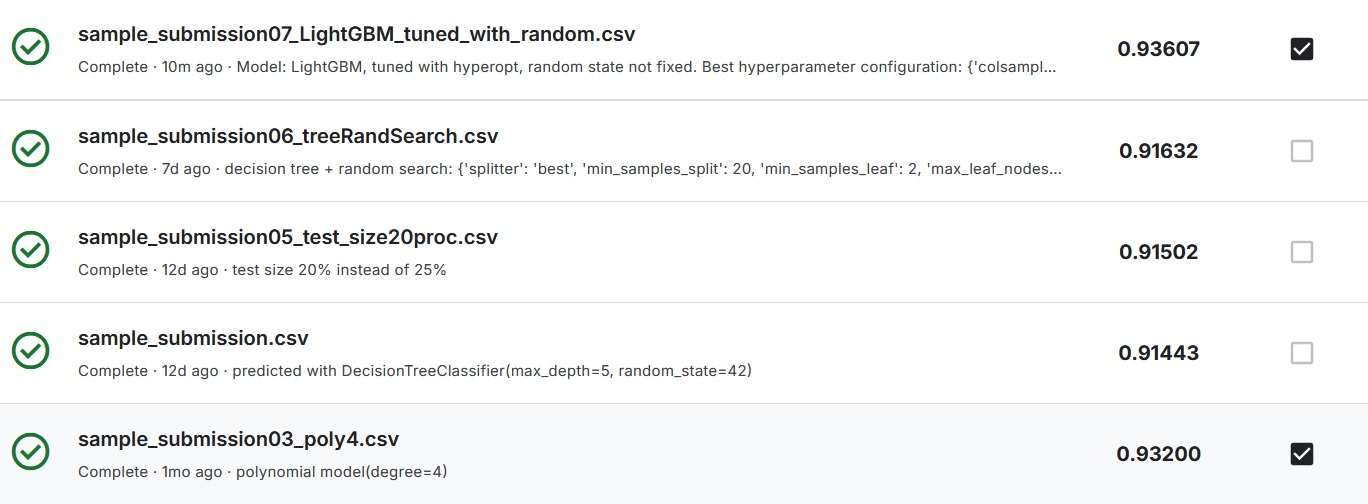

**Висновок**

Для сабміту на kaggle була обрана модель LightGBM з нефіксованим random state в ф-ції fmin тому, що вона видала один з найкращих результатів на валідаційних даних, проте показала кращу здатність генералізувати дані, ніж модель з кращим результатом у цій сесії. Для порівняння:
- XGBoost (з тюнінгом, без фіксації random state, змінюються після перезапуску):
  - AUROC for Training data: 0.95343
  - AUROC for Validation data: 0.93650 - найкраще значення метрики
- LightGBM (з тюнінгом, без фіксації random state, змінюються після перезапуску):
  - AUROC for Training data: 0.94316
  - AUROC for Validation data: 0.93550

Моделі XGBoost і LightGBM з фіксованим random state в ф-ції fmin мали тенденцію до перенавчання у даній сесії.